# QuadConnect public API: statistics in a notebook (use 2)

A data-minded student or the course staff can study QuadConnect's interest data without an account: `/api/summary/` is public and returns JSON. This notebook loads it into pandas, describes the distribution, compares hobbies with student organizations, and measures how concentrated the picks are.

In [1]:
import pandas as pd
import requests

API = "https://manojkmohan43.pythonanywhere.com/api/summary/"
response = requests.get(API, timeout=10)
response.raise_for_status()
df = pd.DataFrame(response.json())
print(f"GET {API} -> HTTP {response.status_code}, {len(df)} rows, columns {list(df.columns)}")
df.head(8)

GET https://manojkmohan43.pythonanywhere.com/api/summary/ -> HTTP 200, 22 rows, columns ['category', 'count', 'type']


,category,count,type
0,Food,4,Hobby / Interest
1,Movies,4,Hobby / Interest
2,Fitness,3,Hobby / Interest
3,Gaming,3,Hobby / Interest
4,Music,3,Hobby / Interest
5,UIUC Esports,3,Registered Student Organization
6,Art,2,Hobby / Interest
7,Basketball,2,Hobby / Interest


## How many students pick each interest

In [2]:
df["count"].describe().round(2)

count    22.00
mean      1.86
std       1.04
min       1.00
25%       1.00
50%       1.50
75%       2.75
max       4.00
Name: count, dtype: float64

## Hobbies compared with student organizations

In [3]:
by_type = (df.groupby("type")["count"]
             .agg(interests="size", picks="sum", mean="mean", median="median", most="max")
             .round(2))
by_type["share_of_picks"] = (by_type["picks"] / by_type["picks"].sum()).map("{:.0%}".format)
by_type

,interests,picks,mean,median,most,share_of_picks
type,,,,,,
Hobby / Interest,12,29,2.42,2.0,4,71%
Registered Student Organization,10,12,1.20,1.0,3,29%


## How concentrated are the picks?

In [4]:
top5 = df.nlargest(5, "count")
share = top5["count"].sum() / df["count"].sum()
above = (df["count"] > df["count"].mean()).sum()
print(f"The five most picked interests ({', '.join(top5['category'])}) hold {share:.0%} of all picks.")
print(f"{above} of {len(df)} interests are picked more often than average ({df['count'].mean():.2f}).")

The five most picked interests (Food, Movies, Fitness, Gaming, Music) hold 41% of all picks.
11 of 22 interests are picked more often than average (1.86).


## Picks per interest, by type

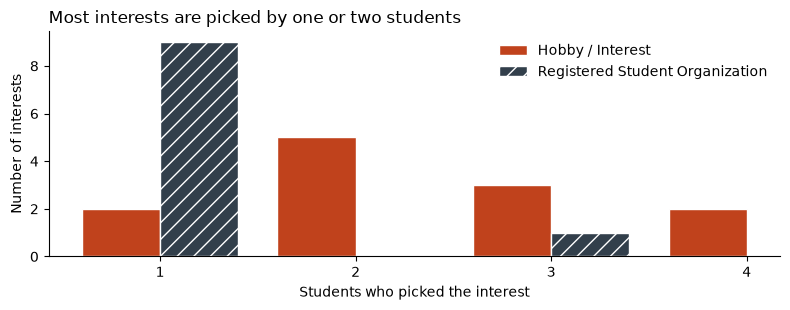

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3.2))
for (kind, group), color, hatch in zip(df.groupby("type"), ["#c0421c", "#323f4b"], ["", "//"]):
    counts = group["count"].value_counts().sort_index()
    ax.bar(counts.index + (-0.2 if hatch == "" else 0.2), counts.values, width=0.4,
           color=color, hatch=hatch, edgecolor="white", label=kind)
ax.set_xlabel("Students who picked the interest")
ax.set_ylabel("Number of interests")
ax.set_xticks(sorted(df["count"].unique()))
ax.set_title("Most interests are picked by one or two students", loc="left")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()